In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as p

# Load the Dataset 

In [2]:
# finpredict was test dataset
fintrain=pd.read_csv(r"C:\Users\KHUSHI PAINTER\OneDrive\Desktop\Project Work of ML\finance_train (Project work in ML).csv")
finpredict=pd.read_csv(r"C:\Users\KHUSHI PAINTER\OneDrive\Desktop\Project Work of ML\finance_test (project work in ML).csv")

In [3]:
fintrain

,REF_NO,children,age_band,status,occupation,occupation_partner,home_status,family_income,self_employed,self_employed_partner,...,Investment.Tax.Saving.Bond,Home.Loan,Online.Purchase.Amount,Revenue.Grid,gender,region,Investment.in.Commudity,Investment.in.Equity,Investment.in.Derivative,Portfolio.Balance
0,2148,1,45-50,Partner,Professional,Professional,Rent Privately,">=35,000",Yes,Yes,...,7.49,2.48,0.0,2,Female,South West,65.87,9.27,30.93,87.48
1,8099,1,61-65,Partner,Retired,Retired,Own Home,"<12,500, >=10,000",No,No,...,0.00,3.99,0.0,2,Female,Unknown,42.46,4.49,26.23,110.73
2,6611,3,31-35,Partner,Professional,Professional,Own Home,">=35,000",No,No,...,0.00,0.00,0.0,2,Male,East Anglia,75.38,0.00,26.66,127.57
3,1950,Zero,55-60,Partner,Professional,Professional,Own Home,">=35,000",No,No,...,2.00,0.00,0.0,2,Female,North West,34.78,6.91,29.24,33.79
4,10857,2,51-55,Partner,Manual Worker,Manual Worker,Own Home,"<27,500, >=25,000",Yes,Yes,...,0.00,0.00,0.0,2,Female,South West,48.58,9.58,20.65,56.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,10391,Zero,71+,Widowed,Retired,Unknown,Own Home,"<10,000, >= 8,000",No,No,...,0.00,0.00,0.0,2,Female,West Midlands,32.19,1.67,20.66,66.26
8120,3955,Zero,61-65,Partner,Retired,Retired,Own Home,"<15,000, >=12,500",No,No,...,0.00,0.00,0.0,2,Male,North West,24.09,0.00,4.17,-2.70
8121,1195,Zero,61-65,Partner,Retired,Retired,Own Home,"<25,000, >=22,500",No,No,...,8.00,0.00,0.0,2,Female,West Midlands,42.98,3.49,16.48,36.72
8122,6581,2,26-30,Partner,Secretarial/Admin,Manual Worker,Own Home,"<30,000, >=27,500",No,No,...,0.00,0.00,0.0,2,Female,Scotland,25.38,0.00,11.99,-11.65


In [4]:
# Columns name of train data
fintrain.columns

Index(['REF_NO', 'children', 'age_band', 'status', 'occupation',
       'occupation_partner', 'home_status', 'family_income', 'self_employed',
       'self_employed_partner', 'year_last_moved', 'TVarea', 'post_code',
       'post_area', 'Average.Credit.Card.Transaction', 'Balance.Transfer',
       'Term.Deposit', 'Life.Insurance', 'Medical.Insurance',
       'Average.A.C.Balance', 'Personal.Loan', 'Investment.in.Mutual.Fund',
       'Investment.Tax.Saving.Bond', 'Home.Loan', 'Online.Purchase.Amount',
       'Revenue.Grid', 'gender', 'region', 'Investment.in.Commudity',
       'Investment.in.Equity', 'Investment.in.Derivative',
       'Portfolio.Balance'],
      dtype='object')

In [5]:
# Shape of train data
fintrain.shape

(8124, 32)

# Split the Dataset

In [6]:
# Split the data into train & test
from sklearn.model_selection import train_test_split

In [7]:
traindf,testdf=train_test_split(fintrain,train_size=0.8,random_state=2374)

In [8]:
print("Shape of traindf:",traindf.shape)
print("Shape of testdf:",testdf.shape)

Shape of traindf: (6499, 32)
Shape of testdf: (1625, 32)


In [9]:
# Create source column on train, test, prediction
traindf["Source"]="Train"
testdf["Source"]="Test"
finpredict["Source"]="Prediction"

In [10]:
# Combine all 3 dataset
fintrain1=pd.concat([traindf,testdf,finpredict],axis=0)

In [11]:
fintrain1.shape

(10155, 33)

In [12]:
fintrain1.columns

Index(['REF_NO', 'children', 'age_band', 'status', 'occupation',
       'occupation_partner', 'home_status', 'family_income', 'self_employed',
       'self_employed_partner', 'year_last_moved', 'TVarea', 'post_code',
       'post_area', 'Average.Credit.Card.Transaction', 'Balance.Transfer',
       'Term.Deposit', 'Life.Insurance', 'Medical.Insurance',
       'Average.A.C.Balance', 'Personal.Loan', 'Investment.in.Mutual.Fund',
       'Investment.Tax.Saving.Bond', 'Home.Loan', 'Online.Purchase.Amount',
       'Revenue.Grid', 'gender', 'region', 'Investment.in.Commudity',
       'Investment.in.Equity', 'Investment.in.Derivative', 'Portfolio.Balance',
       'Source'],
      dtype='object')

In [13]:
fintrain1

,REF_NO,children,age_band,status,occupation,occupation_partner,home_status,family_income,self_employed,self_employed_partner,...,Home.Loan,Online.Purchase.Amount,Revenue.Grid,gender,region,Investment.in.Commudity,Investment.in.Equity,Investment.in.Derivative,Portfolio.Balance,Source
4127,4869,Zero,71+,Single/Never Married,Retired,Unknown,Own Home,Unknown,No,No,...,0.00,0.00,2.0,Female,East Anglia,0.00,7.91,7.91,22.02,Train
3942,8843,Zero,31-35,Partner,Secretarial/Admin,Unknown,Own Home,"<30,000, >=27,500",No,Yes,...,18.46,44.49,2.0,Female,Unknown,47.87,31.72,49.21,124.36,Train
4248,3644,3,71+,Partner,Unknown,Professional,Own Home,">=35,000",No,No,...,0.00,0.00,2.0,Male,East Midlands,48.58,0.00,6.67,81.80,Train
7356,2003,Zero,31-35,Single/Never Married,Business Manager,Unknown,Own Home,">=35,000",No,No,...,29.14,10.48,2.0,Male,West Midlands,75.06,45.78,63.58,222.56,Train
829,8515,Zero,71+,Partner,Retired,Retired,Own Home,"<15,000, >=12,500",No,No,...,0.00,29.48,2.0,Female,South West,16.79,16.73,15.98,48.27,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026,11496,2,41-45,Partner,Professional,Professional,Own Home,"<30,000, >=27,500",No,No,...,0.00,80.92,NaN,Female,North West,0.00,15.98,2.50,29.00,Prediction
2027,11503,1,45-50,Partner,Business Manager,Professional,Own Home,"<30,000, >=27,500",No,No,...,0.00,0.00,NaN,Female,North West,24.39,2.00,16.49,84.08,Prediction
2028,11509,Zero,61-65,Partner,Retired,Retired,Own Home,"< 8,000, >= 4,000",No,No,...,7.49,0.00,NaN,Female,North West,20.59,8.25,13.49,61.10,Prediction
2029,11511,Zero,55-60,Partner,Unknown,Housewife,Own Home,"<27,500, >=25,000",Yes,No,...,11.97,48.98,NaN,Male,North West,86.93,25.59,55.39,170.07,Prediction


In [14]:
# Information about dataset
fintrain1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10155 entries, 4127 to 2030
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   REF_NO                           10155 non-null  int64  
 1   children                         10155 non-null  object 
 2   age_band                         10155 non-null  object 
 3   status                           10155 non-null  object 
 4   occupation                       10155 non-null  object 
 5   occupation_partner               10155 non-null  object 
 6   home_status                      10155 non-null  object 
 7   family_income                    10155 non-null  object 
 8   self_employed                    10155 non-null  object 
 9   self_employed_partner            10155 non-null  object 
 10  year_last_moved                  10155 non-null  int64  
 11  TVarea                           10155 non-null  object 
 12  post_code            

In [15]:
# There are no null values in our data 
# In revenue grid column have null values beacuse of concat the data with test and test data has not revenue grid column
fintrain1.isnull().sum()

REF_NO                                0
children                              0
age_band                              0
status                                0
occupation                            0
occupation_partner                    0
home_status                           0
family_income                         0
self_employed                         0
self_employed_partner                 0
year_last_moved                       0
TVarea                                0
post_code                             0
post_area                             0
Average.Credit.Card.Transaction       0
Balance.Transfer                      0
Term.Deposit                          0
Life.Insurance                        0
Medical.Insurance                     0
Average.A.C.Balance                   0
Personal.Loan                         0
Investment.in.Mutual.Fund             0
Investment.Tax.Saving.Bond            0
Home.Loan                             0
Online.Purchase.Amount                0


In [16]:
# Describe the dataset 
fintrain1.describe()

,REF_NO,year_last_moved,Average.Credit.Card.Transaction,Balance.Transfer,Term.Deposit,Life.Insurance,Medical.Insurance,Average.A.C.Balance,Personal.Loan,Investment.in.Mutual.Fund,Investment.Tax.Saving.Bond,Home.Loan,Online.Purchase.Amount,Revenue.Grid,Investment.in.Commudity,Investment.in.Equity,Investment.in.Derivative,Portfolio.Balance
count,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,10155.000000,8124.000000,10155.000000,10155.000000,10155.000000,10155.000000
mean,5770.830822,1968.376366,23.441757,46.417760,27.579851,66.242131,19.142050,32.084965,26.006003,42.339698,6.112071,4.482002,19.162772,1.893772,36.564886,21.698694,31.988647,90.460237
std,3324.837813,180.202242,50.872127,78.477609,53.952550,95.545316,32.451856,45.486614,84.275743,63.898899,12.833675,9.982641,89.666263,0.308149,42.270530,31.893841,39.106347,107.265475
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-78.430000
25%,2903.500000,1978.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,8.230000,4.670000,8.740000,26.605000
50%,5770.000000,1988.000000,0.000000,17.960000,0.000000,31.980000,0.510000,14.990000,0.000000,23.480000,0.000000,0.000000,0.000000,2.000000,23.980000,12.980000,21.340000,66.200000
75%,8665.500000,1994.000000,23.980000,65.385000,34.990000,94.390000,27.470000,46.480000,21.480000,59.555000,5.975000,4.490000,7.980000,2.000000,50.790000,28.300000,42.980000,125.935000
max,11518.000000,1999.000000,662.260000,2951.760000,784.820000,2930.410000,591.040000,626.240000,4905.930000,2561.270000,156.870000,162.350000,4306.420000,2.000000,1231.090000,1279.100000,1771.160000,4283.560000


# Univariate Analysis

In [17]:
# Drop column REF_NO and Post code
fintrain1.drop('REF_NO', axis=1, inplace=True)
fintrain1.drop('post_code',axis=1, inplace=True)

In [18]:
fintrain1.columns

Index(['children', 'age_band', 'status', 'occupation', 'occupation_partner',
       'home_status', 'family_income', 'self_employed',
       'self_employed_partner', 'year_last_moved', 'TVarea', 'post_area',
       'Average.Credit.Card.Transaction', 'Balance.Transfer', 'Term.Deposit',
       'Life.Insurance', 'Medical.Insurance', 'Average.A.C.Balance',
       'Personal.Loan', 'Investment.in.Mutual.Fund',
       'Investment.Tax.Saving.Bond', 'Home.Loan', 'Online.Purchase.Amount',
       'Revenue.Grid', 'gender', 'region', 'Investment.in.Commudity',
       'Investment.in.Equity', 'Investment.in.Derivative', 'Portfolio.Balance',
       'Source'],
      dtype='object')

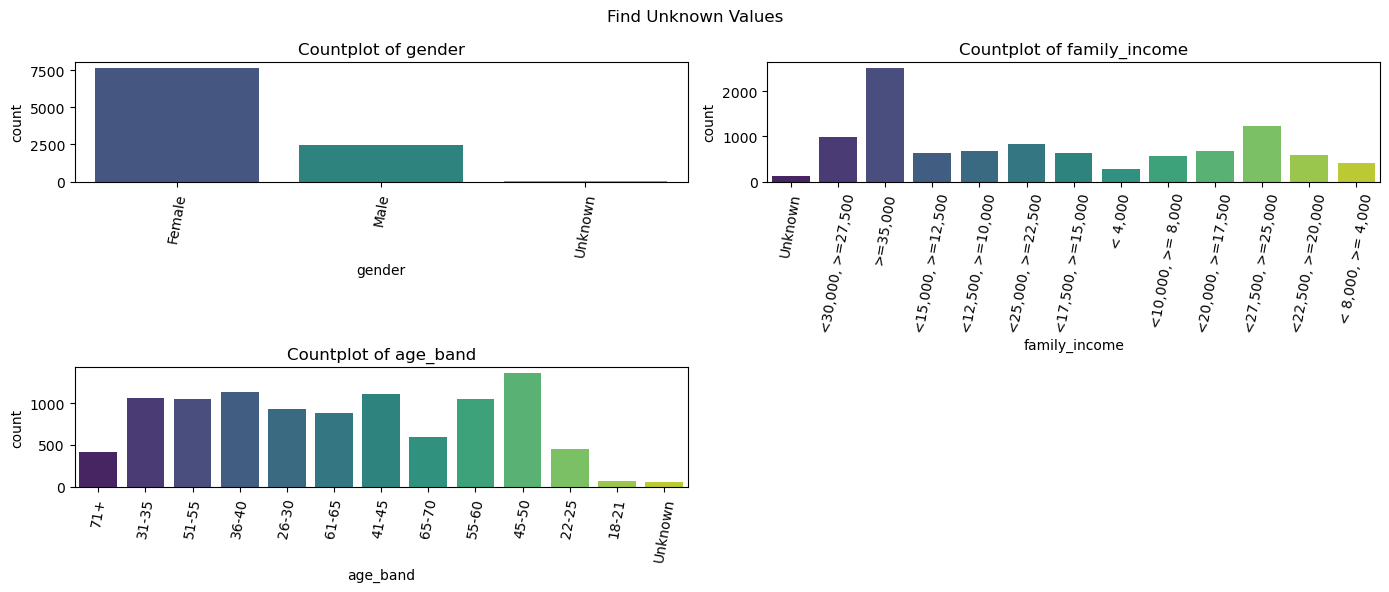

In [19]:
import warnings
warnings.filterwarnings('ignore')
unknown_values = ['gender', 'family_income', 'age_band']

# Define the color palette
palette = 'viridis' 

# Loop through each categorical column and create countplot
p.figure(figsize=(14, 6))
for i, col in enumerate(unknown_values):
    p.subplot(2, 2, i+1)
    sns.countplot(x=col, data=fintrain1, palette=palette)
    p.title(f'Countplot of {col}')
    p.xticks(rotation=80)

p.suptitle("Find Unknown Values")
p.tight_layout()
p.show()

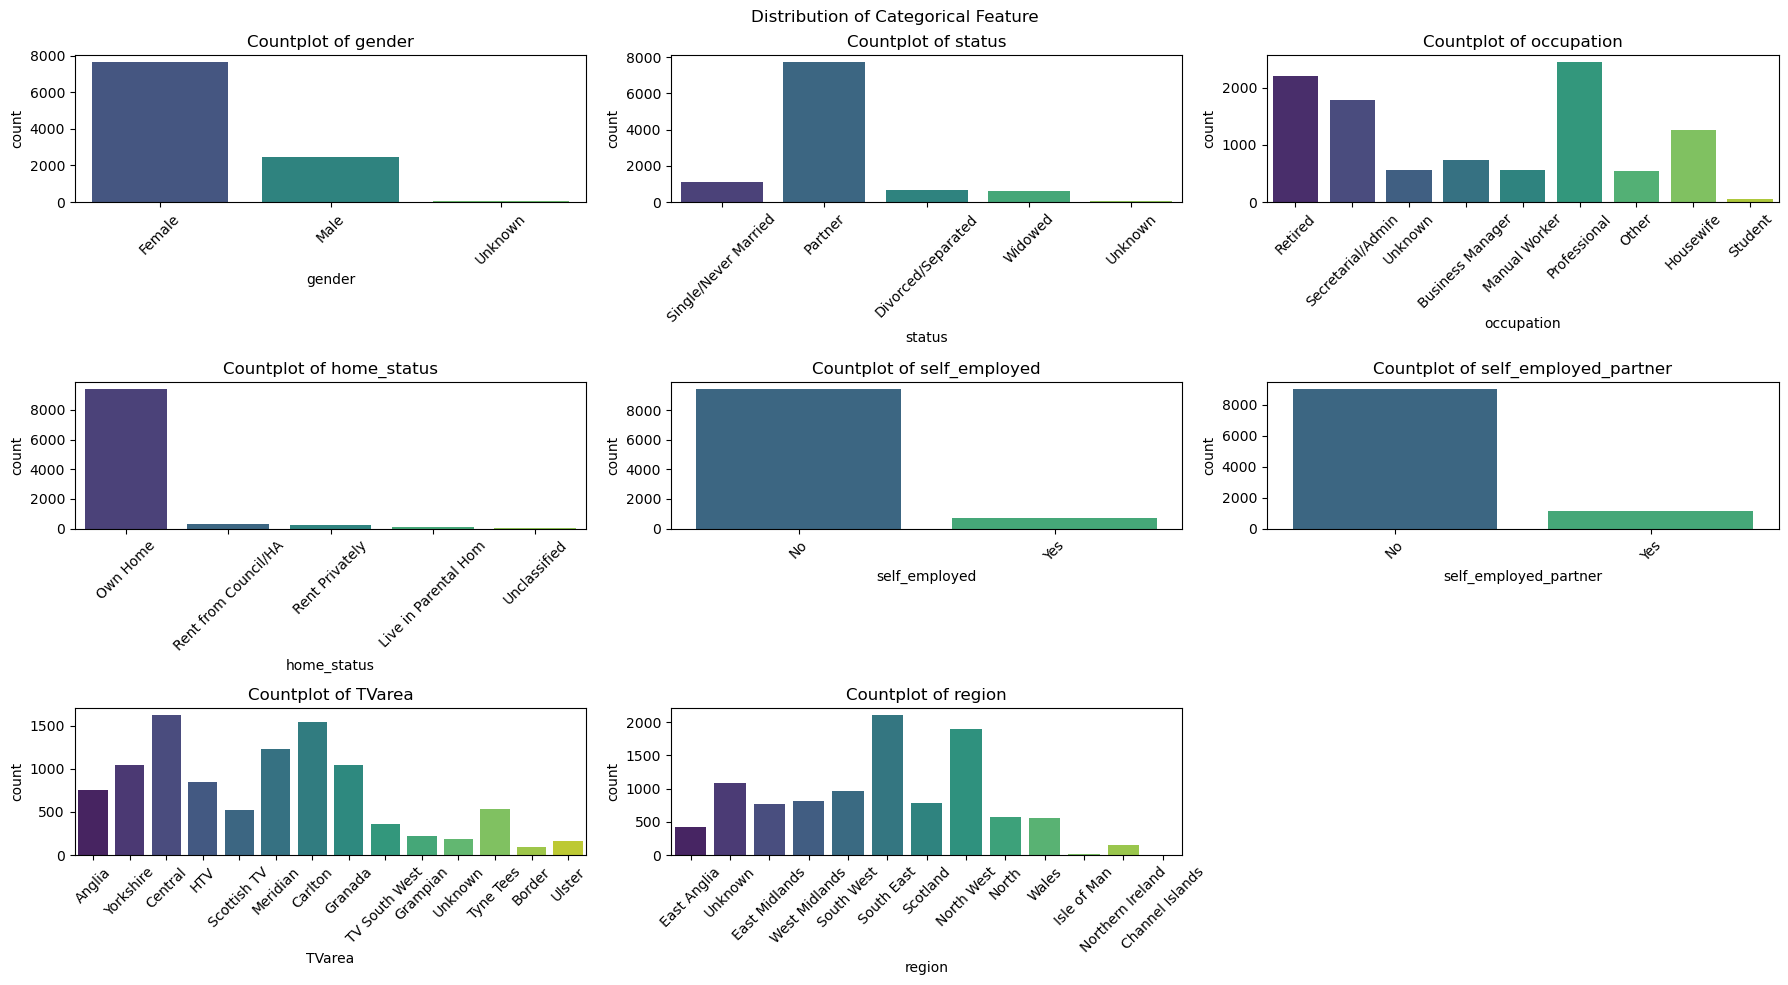

In [20]:
import warnings
warnings.filterwarnings('ignore')
# List of categorical columns to visualize
cat_cols = ['gender', 'status', 'occupation', 'home_status', 
            'self_employed', 'self_employed_partner', 'TVarea', 'region']

# Define the color palette
palette = 'viridis' 

# Loop through each categorical column and create countplot
p.figure(figsize=(18, 10))
for i, col in enumerate(cat_cols):
    p.subplot(3, 3, i+1)
    sns.countplot(x=col, data=fintrain1, palette=palette)
    p.title(f'Countplot of {col}')
    p.xticks(rotation=45)
p.suptitle("Distribution of Categorical Feature")
p.tight_layout()
p.show()

In [21]:
# Converting the children features of 'Zero' with 0
fintrain1['children']=np.where(fintrain1['children']=='Zero',0,fintrain1['children'] )
# Replacing 4+ value to 4 (convert dtype object to int) from children feature
fintrain1['children']=fintrain1['children'].replace(to_replace={'4+':4})

In [22]:
# Find dtype of children column 
# Find unique values of children 
print(fintrain1['children'].dtypes)
print(fintrain1['children'].unique())

object
[0 '3' '1' '2' 4]


In [23]:
# Convert the Children column to Numeric
fintrain1['children'] = pd.to_numeric(fintrain1['children'], errors='coerce')

In [24]:
# Find gender mode for unknown values
gen=fintrain1['gender'].mode()
gen

0    Female
Name: gender, dtype: object

In [25]:
# Convert unknown values into "Female" (with their mode) in gender
fintrain1['gender']=np.where(fintrain1['gender']=='Unknown',"Female",fintrain1['gender'])

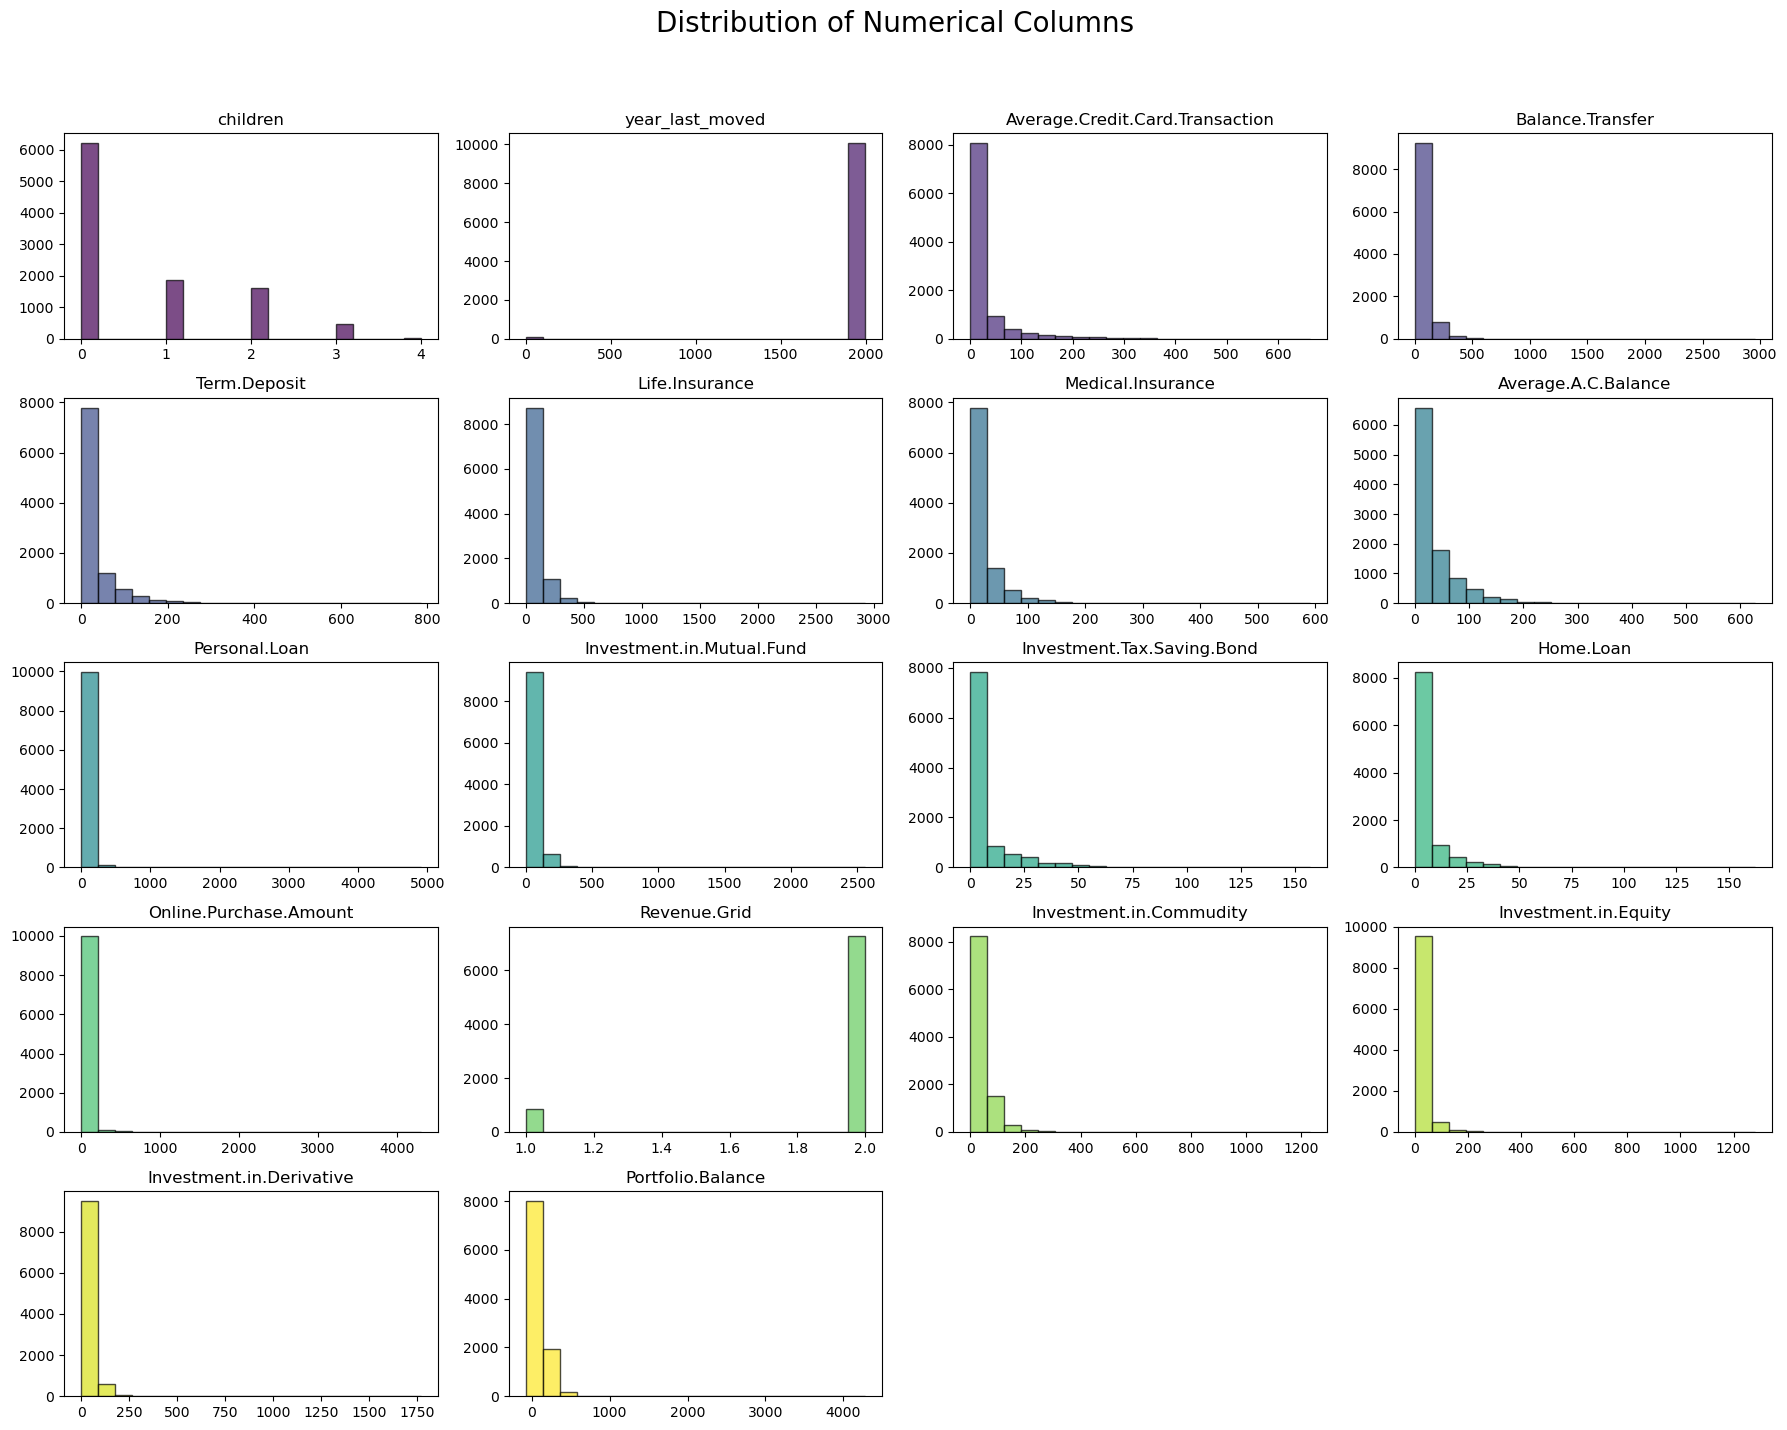

In [26]:
# Countplot for numerical columns for count the unique value in each columns
# Select numerical columns
numerical_cols = fintrain1.select_dtypes(include=['int64', 'float64']).columns

# Define color palette
colors = p.cm.viridis(np.linspace(0, 1, len(numerical_cols)))

# Determine layout for subplots
n_cols = 4  
n_rows = len(numerical_cols) // n_cols + (len(numerical_cols) % n_cols > 0)
fig, axes = p.subplots(n_rows, n_cols, figsize=(18, 15))
axes = axes.flatten()

# Plot histograms with colors
for i, col in enumerate(numerical_cols):
    fintrain1[col].hist(bins=20, ax=axes[i], color=colors[i], alpha=0.7, edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(False)

# Remove any unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Title and layout 
p.suptitle('Distribution of Numerical Columns', fontsize=20)
p.tight_layout(rect=[0, 0.03, 1, 0.95]) 
p.show()

In [27]:
# Count values of Revenue.Grid
fintrain1['Revenue.Grid'].value_counts()

Revenue.Grid
2.0    7261
1.0     863
Name: count, dtype: int64

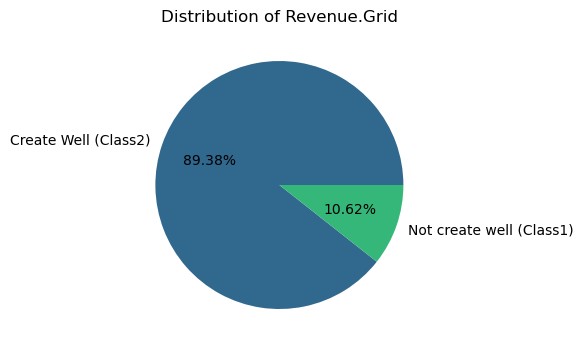

In [28]:
# Define colors using seaborn color palette
colors = sns.color_palette("viridis", 2)
p.figure(figsize=(4, 5))
p.pie(fintrain1['Revenue.Grid'].value_counts(), 
        labels=['Create Well (Class2)', 'Not create well (Class1)'], 
        autopct="%0.2f%%", 
        colors=colors)

p.title("Distribution of Revenue.Grid")
p.show()

In [29]:
# Count Values of age_band
fintrain1['age_band'].value_counts()

age_band
45-50      1359
36-40      1134
41-45      1112
31-35      1061
51-55      1052
55-60      1047
26-30       927
61-65       881
65-70       598
22-25       456
71+         410
18-21        63
Unknown      55
Name: count, dtype: int64

In [30]:
# Converting 45-50 age into 46-50 becasue it overlaping due to 41-45 & 45-50 aslo covert 65-70 to 66-70 and 55-60 to 56-60.
fintrain1['age_band']=np.where(fintrain1['age_band']=="45-50","46-50",fintrain1['age_band'])
fintrain1['age_band']=np.where(fintrain1['age_band']=="65-70","66-70",fintrain1['age_band'])
fintrain1['age_band']=np.where(fintrain1['age_band']=="55-60","56-60",fintrain1['age_band'])

In [31]:
# Find age_band mode for unknown values
age=fintrain1['age_band'].mode()
age

0    46-50
Name: age_band, dtype: object

In [32]:
# Convert unknown values into "46-50" (with their mode) in age_band column
fintrain1['age_band']=np.where(fintrain1['age_band']=='Unknown',"46-50",fintrain1['age_band'])

In [33]:
# Count Values of family_income
fintrain1['family_income'].value_counts()

family_income
>=35,000             2517
<27,500, >=25,000    1227
<30,000, >=27,500     994
<25,000, >=22,500     833
<20,000, >=17,500     683
<12,500, >=10,000     677
<17,500, >=15,000     634
<15,000, >=12,500     629
<22,500, >=20,000     590
<10,000, >= 8,000     563
< 8,000, >= 4,000     402
< 4,000               278
Unknown               128
Name: count, dtype: int64

In [34]:
# Find family_income mode for unknown values
income=fintrain1['family_income'].mode()
income

0    >=35,000
Name: family_income, dtype: object

In [35]:
# Convert unknown values into ">=35,000" (with their mode) in family_income
fintrain1['family_income']=np.where(fintrain1['family_income']=='Unknown',">=35,000",fintrain1['family_income'])

In [36]:
# find unique values of TVarea, post_area & region
print(f"Unique TVarea values: {fintrain1['TVarea'].nunique()}")
print(f"Unique post_area values: {fintrain1['post_area'].nunique()}")
print(f"Unique region values: {fintrain1['region'].nunique()}")

Unique TVarea values: 14
Unique post_area values: 2039
Unique region values: 13


In [37]:
# Drop post_area column because it contains 2039 unique values 
fintrain1=fintrain1.drop('post_area',axis=1)

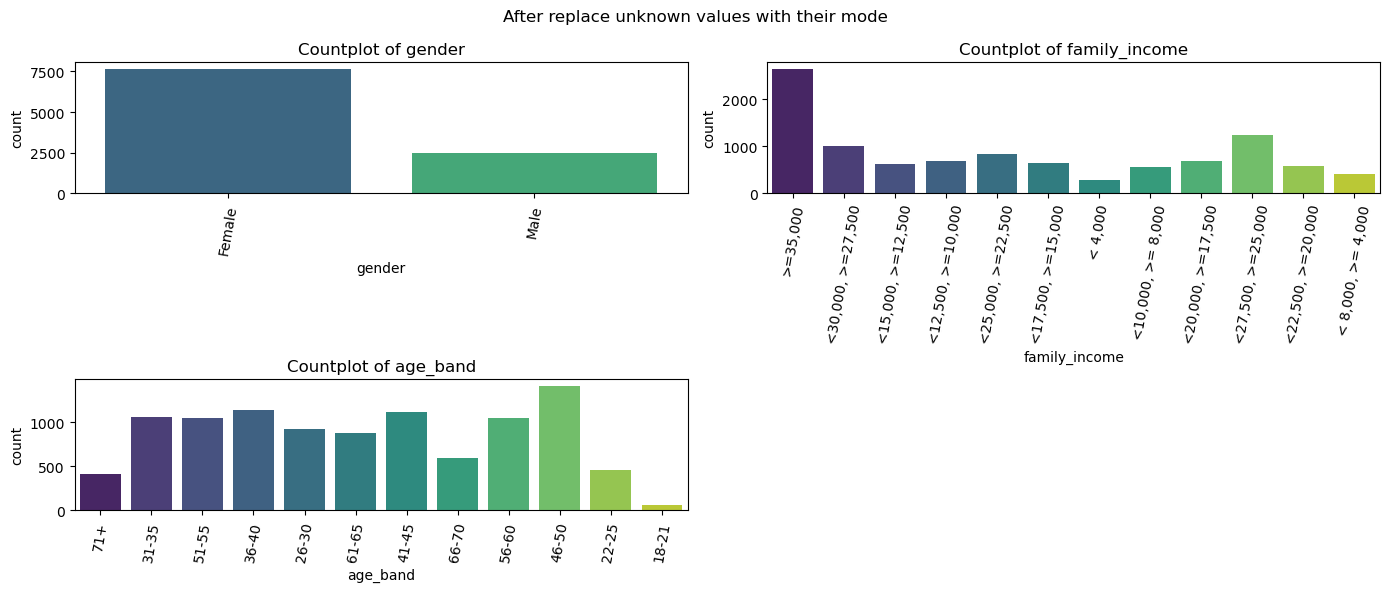

In [38]:
# List of categorical columns to visualize
cat_cols = ['gender', 'family_income', 'age_band']

# Define the color palette
palette = 'viridis'  

# Loop through each categorical column and create countplot
p.figure(figsize=(14, 6))
for i, col in enumerate(cat_cols):
    p.subplot(2, 2, i+1)
    sns.countplot(x=col, data=fintrain1, palette=palette)
    p.title(f'Countplot of {col}')
    p.xticks(rotation=80)
p.suptitle("After replace unknown values with their mode")
p.tight_layout()
p.show()

# Find Outliers

In [39]:
# Select numerical columns
num_cols = fintrain1.select_dtypes(include=['number']).columns
num_cols = num_cols.drop('Revenue.Grid')

# Detect outliers using IQR
Q1 = fintrain1[num_cols].quantile(0.25)
Q3 = fintrain1[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Define outlier condition
outlier_condition = (fintrain1[num_cols] < (Q1 - 1.5 * IQR)) | (fintrain1[num_cols] > (Q3 + 1.5 * IQR))

# Count outliers in each column
outliers_count = outlier_condition.sum()
print(outliers_count)

# Get rows that contain outliers
outlier_rows = fintrain1[outlier_condition.any(axis=1)]
print(outlier_rows)

children                            492
year_last_moved                     253
Average.Credit.Card.Transaction    1290
Balance.Transfer                    724
Term.Deposit                        969
Life.Insurance                      554
Medical.Insurance                   756
Average.A.C.Balance                 551
Personal.Loan                      1390
Investment.in.Mutual.Fund           527
Investment.Tax.Saving.Bond         1583
Home.Loan                          1429
Online.Purchase.Amount             1787
Investment.in.Commudity             524
Investment.in.Equity                619
Investment.in.Derivative            563
Portfolio.Balance                   496
dtype: int64
      children age_band                status         occupation  \
3942         0    31-35               Partner  Secretarial/Admin   
4248         3      71+               Partner            Unknown   
7356         0    31-35  Single/Never Married   Business Manager   
829          0      71+            

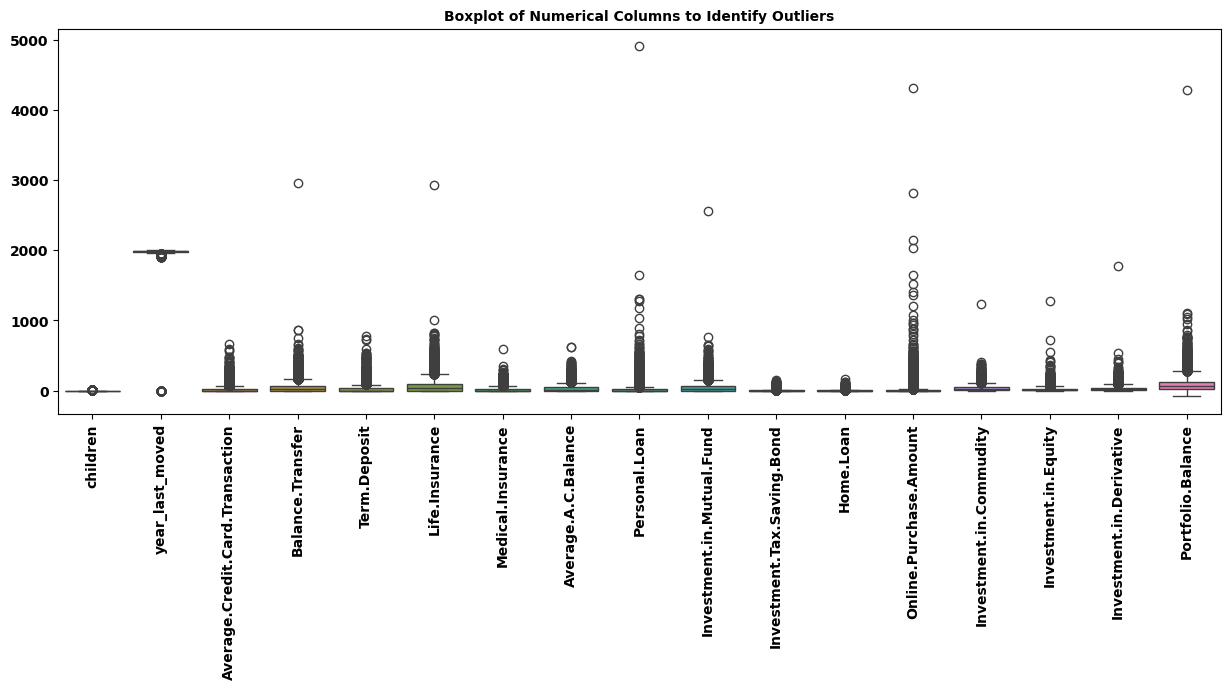

In [40]:
# Find the outliers using boxplot on all numerical columns
p.figure(figsize=(15, 5))
sns.boxplot(data=fintrain1[num_cols])
p.xticks(rotation=90, fontsize=10, fontweight='bold')
p.yticks(fontsize=10, fontweight='bold')
p.title('Boxplot of Numerical Columns to Identify Outliers', fontsize=10, fontweight='bold')
p.show()

# Remove Outliers

In [42]:
# We use capping for remove the outliers
for col in num_cols:
    lower_bound = Q1[col] - 1.5 * IQR[col]
    upper_bound = Q3[col] + 1.5 * IQR[col]
    fintrain1[col] = fintrain1[col].clip(lower=lower_bound, upper=upper_bound)

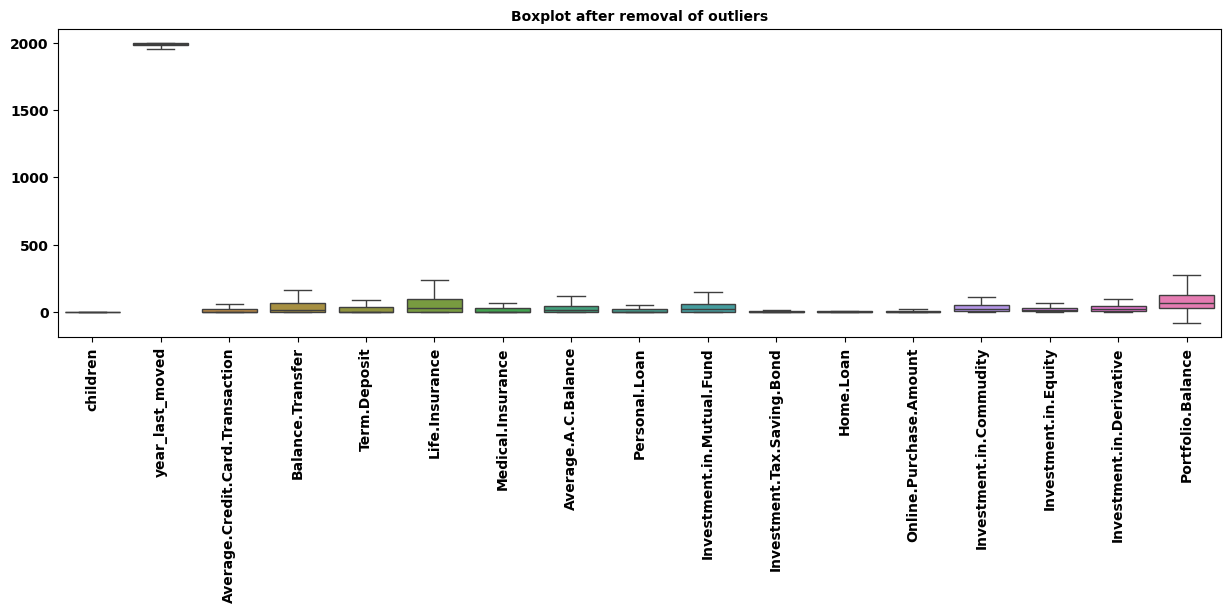

In [43]:
# After removing Outliers we plot the box plot 
# We have no outliers now 
p.figure(figsize=(15, 4))
sns.boxplot(data=fintrain1[num_cols])
p.xticks(rotation=90, fontsize=10, fontweight='bold')
p.yticks(fontsize=10, fontweight='bold')
p.title('Boxplot after removal of outliers', fontsize=10, fontweight='bold')
p.show()

# Correlation between numerical columns

In [45]:
# Find numerical columns
numerical_cols = fintrain1.select_dtypes(include=['int64', 'float64']).columns
print("\n--- Numerical Columns ---")
print(list(numerical_cols))


--- Numerical Columns ---
['children', 'year_last_moved', 'Average.Credit.Card.Transaction', 'Balance.Transfer', 'Term.Deposit', 'Life.Insurance', 'Medical.Insurance', 'Average.A.C.Balance', 'Personal.Loan', 'Investment.in.Mutual.Fund', 'Investment.Tax.Saving.Bond', 'Home.Loan', 'Online.Purchase.Amount', 'Revenue.Grid', 'Investment.in.Commudity', 'Investment.in.Equity', 'Investment.in.Derivative', 'Portfolio.Balance']


In [46]:
# Calculate correlation for numerical columns
corr_num = fintrain1[fintrain1["Source"] == "Train"][numerical_cols].corr()

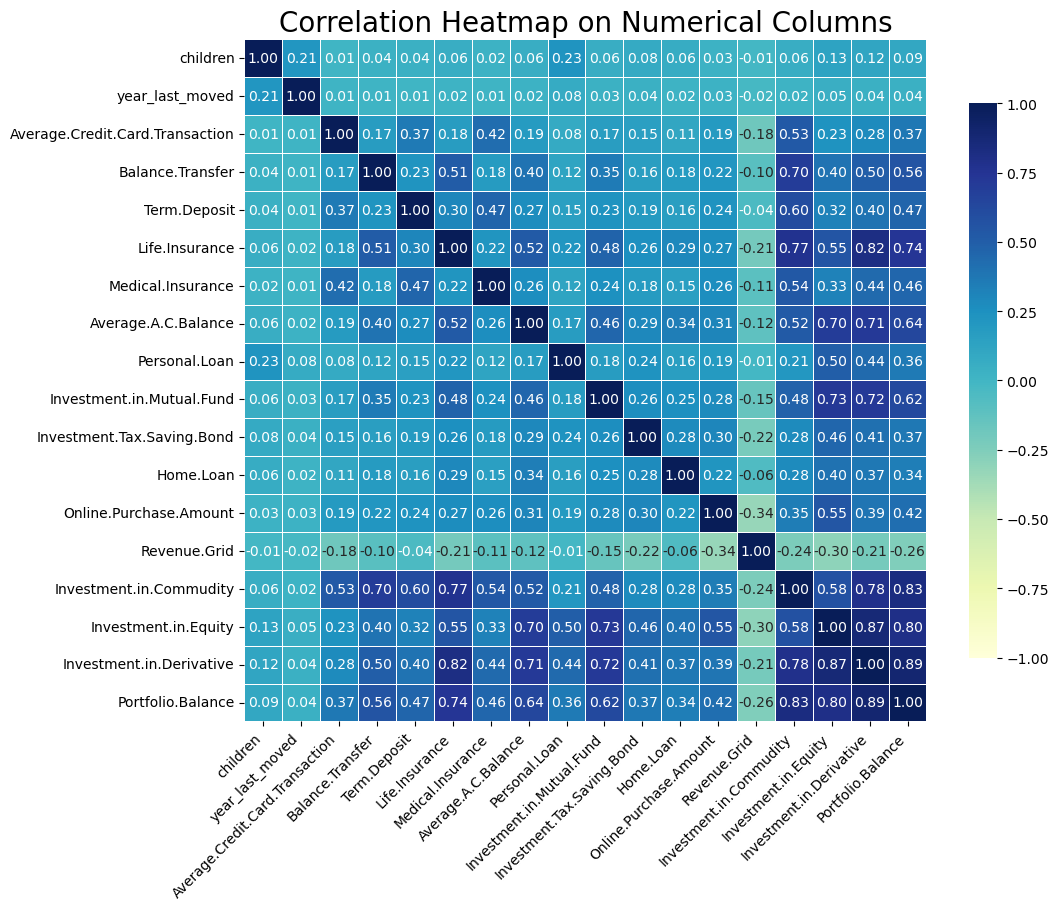

In [47]:
# Plot heatmap 
p.figure(figsize=(11, 9))
sns.heatmap(corr_num, annot=True, fmt=".2f", cmap='YlGnBu', vmin=-1, vmax=1, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
p.title("Correlation Heatmap on Numerical Columns", fontsize=20)
p.xticks(rotation=45, ha='right')
p.yticks(rotation=0)
p.show()

# Encoding

In [48]:
# Ordinal encoding for age_band
age_band_mapping = {
    '18-21': 1, '22-25': 2, '26-30': 3, '31-35': 4, '36-40': 5,
    '41-45': 6, '46-50': 7, '51-55': 8, '56-60': 9, '61-65': 10, '66-70': 11, '71+':12
}

# Ordinal encoding for family_income
family_income_mapping = {
    '< 4,000': 1, '< 8,000, >= 4,000': 2, '<10,000, >= 8,000': 3, '<12,500, >=10,000': 4,
    '<15,000, >=12,500': 5, '<17,500, >=15,000': 6, '<20,000, >=17,500': 7,
    '<22,500, >=20,000': 8, '<25,000, >=22,500': 9, '<27,500, >=25,000': 10,
    '<30,000, >=27,500': 11, '>=35,000': 12
}

# Binary encoding for gender
gender_mapping={
    'Male':1, 'Female':2
}

# Map the columns
fintrain1['age_band'] = fintrain1['age_band'].map(age_band_mapping)
fintrain1['family_income'] = fintrain1['family_income'].map(family_income_mapping)
fintrain1['gender']=fintrain1['gender'].map(gender_mapping)

In [49]:
# Apply one-hot encoding to the specified columns
columns_to_encode = ['status', 'occupation', 'occupation_partner', 'home_status', 'self_employed', 'self_employed_partner', 'TVarea','region', 'Source']
fintrain_encoded = pd.get_dummies(fintrain1, columns=columns_to_encode, drop_first=True, dtype=int)  

In [50]:
fintrain_encoded

,children,age_band,family_income,year_last_moved,Average.Credit.Card.Transaction,Balance.Transfer,Term.Deposit,Life.Insurance,Medical.Insurance,Average.A.C.Balance,...,region_North West,region_Northern Ireland,region_Scotland,region_South East,region_South West,region_Unknown,region_Wales,region_West Midlands,Source_Test,Source_Train
4127,0.0,12,12,1998,0.00,0.0000,0.000,0.00,0.000,5.99,...,0,0,0,0,0,0,0,0,0,1
3942,0.0,4,11,1992,11.49,34.9900,24.990,167.90,0.000,85.44,...,0,0,0,0,0,1,0,0,0,1
4248,2.5,12,12,1990,0.00,163.4625,0.000,39.99,0.000,0.00,...,0,0,0,0,0,0,0,0,0,1
7356,0.0,4,12,1998,49.98,128.9300,49.980,119.93,26.470,92.85,...,0,0,0,0,0,0,0,1,0,1
829,0.0,12,5,1982,58.96,0.0000,0.000,24.99,0.000,58.92,...,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026,2.0,6,11,1994,0.00,0.0000,0.000,0.00,0.000,0.00,...,1,0,0,0,0,0,0,0,0,0
2027,1.0,7,11,1975,0.00,34.9900,0.000,86.97,0.000,0.00,...,1,0,0,0,0,0,0,0,0,0
2028,0.0,10,2,1978,9.99,24.4900,29.480,13.99,24.990,29.99,...,1,0,0,0,0,0,0,0,0,0
2029,0.0,9,10,1982,21.98,1.0300,87.475,197.32,42.440,48.33,...,1,0,0,0,0,0,0,0,0,0


In [51]:
fintrain_encoded.shape

(10155, 74)

# Separate all 3 datasets

In [52]:
# Separate all 3 dataset into traindf, testdf and finpredict
traindf=fintrain_encoded[fintrain_encoded["Source_Train"]==1].drop(["Source_Train","Source_Test"],axis=1).copy()
testdf=fintrain_encoded[fintrain_encoded["Source_Test"]==1].drop(["Source_Train","Source_Test"],axis=1).copy()
finpredict=fintrain_encoded[(fintrain_encoded["Source_Train"]==0) & (fintrain_encoded["Source_Test"]==0)].drop(["Source_Train","Source_Test"],axis=1).copy()

In [53]:
print("Shape of traindf after separate 3 dataset:",traindf.shape)
print("Shape of testdf after separate 3 dataset:",testdf.shape)
print("Shape of finpredict after separate 3 dataset:",finpredict.shape)

Shape of traindf after separate 3 dataset: (6499, 72)
Shape of testdf after separate 3 dataset: (1625, 72)
Shape of finpredict after separate 3 dataset: (2031, 72)


# ANOVA F-Test

In [54]:
# Drop rows with NaN in target temporarily
traindf_clean = traindf.dropna(subset=['Revenue.Grid'])

# Separate features and target
X = traindf_clean.drop(columns=['Revenue.Grid'])
X=X.clip(lower=0)
y = traindf_clean['Revenue.Grid']

In [55]:
from sklearn.feature_selection import SelectKBest, f_classif

# Apply ANOVA F-Test and select top 10 features
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X, y)  

# Get selected feature names
selected_features_anova = X.columns[selector.get_support()]

# Store results in DataFrame
anova_results = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,  
    'P-Value': selector.pvalues_  
})

# Sort by F-score and keep top 10
anova_results = anova_results.sort_values(by='F-Score', ascending=False).head(10)

print("Top 10 Selected Features:\n", selected_features_anova)
print("\nANOVA F-Test Results:\n", anova_results)

Top 10 Selected Features:
 Index(['Average.Credit.Card.Transaction', 'Life.Insurance',
       'Average.A.C.Balance', 'Investment.in.Mutual.Fund',
       'Investment.Tax.Saving.Bond', 'Online.Purchase.Amount',
       'Investment.in.Commudity', 'Investment.in.Equity',
       'Investment.in.Derivative', 'Portfolio.Balance'],
      dtype='object')

ANOVA F-Test Results:
                             Feature     F-Score        P-Value
14           Online.Purchase.Amount  823.005504  1.592339e-170
17             Investment.in.Equity  643.055214  2.321763e-135
19                Portfolio.Balance  466.084570  6.891784e-100
16          Investment.in.Commudity  385.920636   1.633116e-83
12       Investment.Tax.Saving.Bond  331.682870   2.542490e-72
18         Investment.in.Derivative  304.339579   1.211763e-66
7                    Life.Insurance  294.783368   1.184783e-64
4   Average.Credit.Card.Transaction  221.679605   2.513657e-49
11        Investment.in.Mutual.Fund  148.898377   7.072877e-34


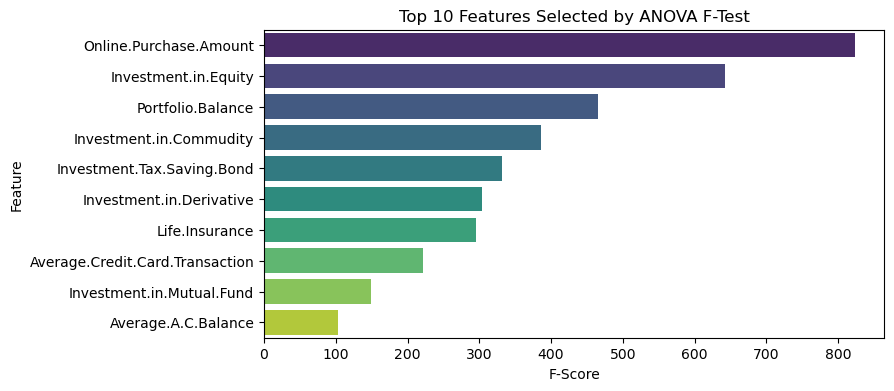

In [56]:
# Plot the top 10 features
p.figure(figsize=(8, 4))
sns.barplot(x='F-Score', y='Feature', data=anova_results, palette='viridis')
p.xlabel("F-Score")
p.ylabel("Feature")
p.title("Top 10 Features Selected by ANOVA F-Test")
p.show()

# Recursive Feature Elimination (RFE)

In [57]:
from sklearn.feature_selection import  RFE
from sklearn.linear_model import LogisticRegression

In [58]:
# Initialize the Logistic Regression model
logreg = LogisticRegression(max_iter=1000, random_state=2374)

# Apply RFE
rfe_selector = RFE(estimator=logreg, n_features_to_select=10, step=1)
rfe_selector = rfe_selector.fit(X, y)

# Get selected feature names
selected_features_rfe = X.columns[rfe_selector.support_]

print("Selected Features by RFE:")
print(selected_features_rfe)

Selected Features by RFE:
Index(['status_Widowed', 'occupation_Housewife', 'occupation_Student',
       'occupation_partner_Housewife', 'occupation_partner_Student',
       'home_status_Rent Privately', 'self_employed_Yes', 'TVarea_Grampian',
       'region_Isle of Man', 'region_South West'],
      dtype='object')


# Correlation Matrix

In [59]:
# Calculate correlation matrix
corr_matrix = fintrain_encoded.corr()

In [60]:
# Unstack and sort correlation matrix
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)

# Drop self-correlations
corr_pairs = corr_pairs[corr_pairs < 1]

# Get top N correlated pairs
top_n = 10
top_corr_pairs = corr_pairs.drop_duplicates().head(top_n)
print("Top Correlated Feature Pairs:\n", top_corr_pairs)

Top Correlated Feature Pairs:
 Portfolio.Balance         Investment.in.Derivative    0.889982
Investment.in.Derivative  Investment.in.Equity        0.868759
region_North              TVarea_Tyne Tees            0.829454
Investment.in.Commudity   Portfolio.Balance           0.826342
Investment.in.Derivative  Life.Insurance              0.816740
region_Scotland           TVarea_Scottish TV          0.801515
Investment.in.Equity      Portfolio.Balance           0.790757
Investment.in.Derivative  Investment.in.Commudity     0.777119
Investment.in.Commudity   Life.Insurance              0.775335
TVarea_Yorkshire          region_Unknown              0.771777
dtype: float64


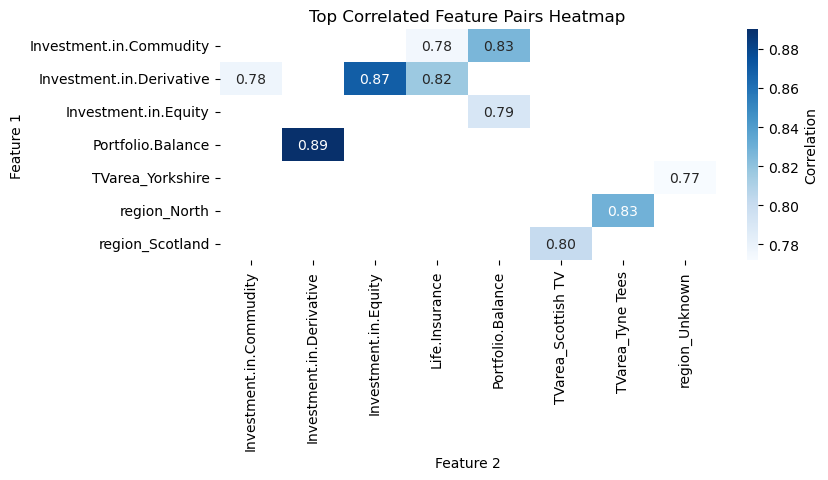

In [61]:
# Convert the top correlated pairs to a DataFrame
top_corr_df = top_corr_pairs.reset_index()
top_corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Create a pivot table for the heatmap
heatmap_data = top_corr_df.pivot_table(index='Feature 1', columns='Feature 2', values='Correlation')

# Create the heatmap
p.figure(figsize=(8, 3))
sns.heatmap(heatmap_data, annot=True, cmap='Blues', fmt='.2f', cbar_kws={'label': 'Correlation'})
p.title('Top Correlated Feature Pairs Heatmap')
p.show()

# Model Development 

# Split the fintrain_encoded data 

In [62]:
# Split the fintrain_encoded data
traindf,testdf=train_test_split(fintrain_encoded, train_size=0.8, random_state=6348)

In [63]:
# Separate independent variable and dependent variable
trainX = traindf_clean.drop(["Revenue.Grid", "Source_Train", "Source_Test"], axis=1, errors='ignore')
trainY = traindf_clean["Revenue.Grid"]
# test data
testdf_clean = testdf.dropna(subset=["Revenue.Grid"])  
testX = testdf_clean.drop(["Revenue.Grid", "Source_Train", "Source_Test"], axis=1, errors='ignore')  
testY = testdf_clean["Revenue.Grid"]

In [64]:
# Idenify the scale of data
print(fintrain_encoded.describe().T[['min', 'max', 'mean', 'std']])

                                    min      max         mean        std
children                            0.0     2.50     0.619596   0.856707
age_band                            1.0    12.00     6.734318   2.735234
family_income                       1.0    12.00     8.308223   3.407855
year_last_moved                  1954.0  1999.00  1984.843919  11.483250
Average.Credit.Card.Transaction     0.0    59.95    14.151388  21.884726
...                                 ...      ...          ...        ...
region_Unknown                      0.0     1.00     0.106352   0.308302
region_Wales                        0.0     1.00     0.054751   0.227505
region_West Midlands                0.0     1.00     0.080748   0.272462
Source_Test                         0.0     1.00     0.160020   0.366642
Source_Train                        0.0     1.00     0.639980   0.480029

[74 rows x 4 columns]


# Standardization on fintrain_encoded data

In [65]:
from sklearn.preprocessing import StandardScaler
sd=StandardScaler().fit(trainX)
trainsd=sd.transform(trainX)
testsd=sd.transform(testX)

In [66]:
trainstd=pd.DataFrame(trainsd, columns=trainX.columns)
teststd=pd.DataFrame(testsd, columns=testX.columns)

In [67]:
# import classification_report, confusion_matrix, accuracy_score 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Logistic Regression 

In [68]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression().fit(trainstd,trainY)
# Prediction of Logistics Regression 
lrpredict=lr.predict(teststd)

# Evaluation Metrics

In [69]:
# Confusion matrix of logistic regression 
print(confusion_matrix(testY,lrpredict))

[[  56  116]
 [  27 1428]]


In [70]:
# Classification Report of Logistic Regression
print(classification_report(testY,lrpredict))

              precision    recall  f1-score   support

         1.0       0.67      0.33      0.44       172
         2.0       0.92      0.98      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.80      0.65      0.70      1627
weighted avg       0.90      0.91      0.90      1627



In [71]:
# Accuracy Score of Logistic Regression
from sklearn.metrics import accuracy_score
accuracy_score(testY, lrpredict)*100

91.21081745543947

# Decision Tree

In [72]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier, plot_tree
dt=DecisionTreeClassifier().fit(trainstd, trainY)
# Prediction of Decision Tree
dtpredict=dt.predict(teststd)

# Evaluation Metrics

In [73]:
# Confusion matrix of decision tree
print(confusion_matrix(testY, dtpredict))

[[ 154   18]
 [  19 1436]]


In [74]:
# Classification Report of Decision Tree
print(classification_report(testY, dtpredict))

              precision    recall  f1-score   support

         1.0       0.89      0.90      0.89       172
         2.0       0.99      0.99      0.99      1455

    accuracy                           0.98      1627
   macro avg       0.94      0.94      0.94      1627
weighted avg       0.98      0.98      0.98      1627



In [75]:
# Accuracy Score of Decision Tree
accuracy_score(testY, dtpredict)*100

97.7258758451137

# Random Forest 

In [76]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier().fit(trainstd, trainY)
# Predict of Random Forest Model
rfpredict=rf.predict(teststd)

# Evaluation Metrics

In [77]:
# Confusion matrix of random forest 
print(confusion_matrix(testY, rfpredict))

[[ 133   39]
 [   0 1455]]


In [78]:
# Classification Report of Random forest model
print(classification_report(testY, rfpredict))

              precision    recall  f1-score   support

         1.0       1.00      0.77      0.87       172
         2.0       0.97      1.00      0.99      1455

    accuracy                           0.98      1627
   macro avg       0.99      0.89      0.93      1627
weighted avg       0.98      0.98      0.97      1627



In [79]:
# Accuracy Score of Random Forest Model
accuracy_score(testY, rfpredict)*100

97.60295021511986

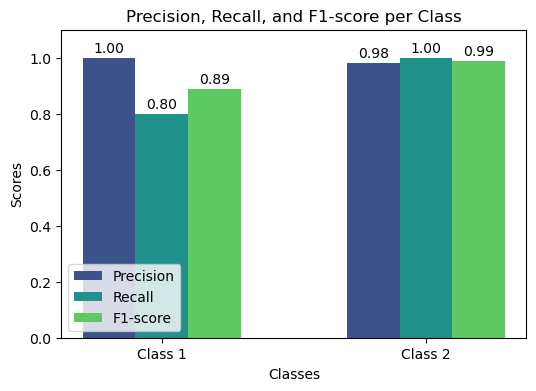

In [80]:
# Values extracted from the classification report
labels = ['Class 1', 'Class 2']
precision = [1.00, 0.98]
recall = [0.80, 1.00]
f1_score = [0.89, 0.99]

x = np.arange(len(labels))  
width = 0.2 

# color palette 
colors = sns.color_palette("viridis", 3)

# Create bar chart
fig, ax = p.subplots(figsize=(6, 4))
rects1 = ax.bar(x - width, precision, width, label='Precision', color=colors[0])
rects2 = ax.bar(x, recall, width, label='Recall', color=colors[1])
rects3 = ax.bar(x + width, f1_score, width, label='F1-score', color=colors[2])

# Labels and title
ax.set_xlabel("Classes")
ax.set_ylabel("Scores")
ax.set_title("Precision, Recall, and F1-score per Class")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)  
ax.legend()

# Display values on top of bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, height + 0.02, f"{height:.2f}", 
                ha='center', fontsize=10)
p.show()

# Heatmap of confusion Matrix(Random Forest)

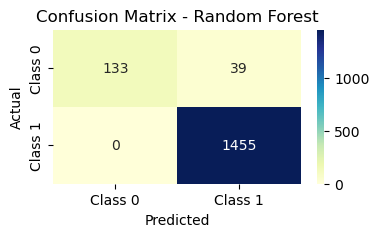

In [81]:
rf_cm = confusion_matrix(testY, rfpredict)
# Function to plot confusion matrix
def plot_confusion_matrix(cm, rf):
    p.figure(figsize=(4, 2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    p.xlabel("Predicted")
    p.ylabel("Actual")
    p.title(f"Confusion Matrix - {rf}")
    p.show()
plot_confusion_matrix(rf_cm, "Random Forest")


# Support Vector Machine

In [82]:
from sklearn.svm import SVC
svm=SVC().fit(trainstd, trainY)
# Predict of Support Vector Machine
svmpredict=svm.predict(teststd)

# Evaluation Metrics

In [83]:
# Confusion matrix of Support Vector Machine 
print(confusion_matrix(testY, svmpredict))

[[  26  146]
 [   0 1455]]


In [84]:
# Classification report of Support Vector Machine
print(classification_report(testY,svmpredict))

              precision    recall  f1-score   support

         1.0       1.00      0.15      0.26       172
         2.0       0.91      1.00      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.95      0.58      0.61      1627
weighted avg       0.92      0.91      0.88      1627



In [85]:
# Accuracy Score of Support Vector Machine
accuracy_score(testY,svmpredict)*100

91.02642901044868

# K-Nearest Neighbours

In [86]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier().fit(trainstd, trainY)
# Prediction of K-Nearest Neighbours
knnpredict=knn.predict(teststd)

  File "C:\Users\KHUSHI PAINTER\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\KHUSHI PAINTER\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\KHUSHI PAINTER\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\KHUSHI PAINTER\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


# Evaluation Metrics

In [87]:
# Confusion matrix of K-Nearest Neighbours
print(confusion_matrix(testY, knnpredict))

[[  20  152]
 [  13 1442]]


In [88]:
# Classification Report of K-Nearest Neighbours 
print(classification_report(testY,knnpredict))

              precision    recall  f1-score   support

         1.0       0.61      0.12      0.20       172
         2.0       0.90      0.99      0.95      1455

    accuracy                           0.90      1627
   macro avg       0.76      0.55      0.57      1627
weighted avg       0.87      0.90      0.87      1627



In [89]:
# Accuracy Score of K-Nearest Neighbours
accuracy_score(testY, knnpredict)*100

89.85863552550707

# Model Devlopment with RFE and ANOVA top features:

In [90]:
# Combine ANOVA & RFE features 
anova = list(set(selected_features_rfe).union(set(selected_features_anova)))
print("Selected Features_both (RFE + ANOVA):", anova)

Selected Features_both (RFE + ANOVA): ['region_Isle of Man', 'region_South West', 'Average.Credit.Card.Transaction', 'occupation_partner_Student', 'status_Widowed', 'Life.Insurance', 'Investment.in.Commudity', 'home_status_Rent Privately', 'Investment.in.Mutual.Fund', 'Average.A.C.Balance', 'Investment.Tax.Saving.Bond', 'Portfolio.Balance', 'Investment.in.Derivative', 'occupation_partner_Housewife', 'occupation_Housewife', 'occupation_Student', 'TVarea_Grampian', 'Investment.in.Equity', 'Online.Purchase.Amount', 'self_employed_Yes']


In [91]:
# separate independent and dependent variable 
trainX_selected_anova = trainX[anova]
testX_selected_anova = testX[anova]

print("Final Train Shape:", trainX_selected_anova.shape)
print("Final Test Shape:", testX_selected_anova.shape)

Final Train Shape: (6499, 20)
Final Test Shape: (1627, 20)


# Standardization on selected_features

In [92]:
scaler_anova=StandardScaler().fit(trainX_selected_anova)

# fit on training data & transform both train and test sets
trainX_anova=scaler_anova.fit_transform(trainX_selected_anova)
testX_anova=scaler_anova.fit_transform(testX_selected_anova)

# conert back to dataframe
trainX_anova=pd.DataFrame(trainX_anova)
testX_anova=pd.DataFrame(testX_anova)

# Logistic Regression with top feature (RFE and ANOVA)

In [93]:
# Model Development 
lr1=LogisticRegression().fit(trainX_anova,trainY)
# Prediction of logistics regression with RFE and ANOVA
lr1predict=lr1.predict(testX_anova)

# Evaluation Metrics

In [94]:
# Confuison matrix of logistic regression with RFE and ANOVA
print(confusion_matrix(testY, lr1predict))

[[  39  133]
 [  20 1435]]


In [95]:
# Classification report of logistics regression with RFE and ANOVA
print(classification_report(testY,lr1predict))

              precision    recall  f1-score   support

         1.0       0.66      0.23      0.34       172
         2.0       0.92      0.99      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.79      0.61      0.64      1627
weighted avg       0.89      0.91      0.88      1627



In [96]:
# Accuracy Score of logistics regression with RFE and ANOVA
accuracy_score(testY,lr1predict)*100

90.59618930547019

# Decision Tree with top feature (RFE and ANOVA)

In [97]:
# Model Development 
dt1=DecisionTreeClassifier().fit(trainX_anova,trainY)
# Prediction of Decision Tree with RFE and ANOVA
dt1predict=dt1.predict(testX_anova)

# Evaluation Metrics

In [98]:
# Confusion matrix of decision tree with RFE and ANOVA
print(confusion_matrix(testY, dt1predict))

[[  53  119]
 [  37 1418]]


In [99]:
# Classification report of Decision Tree with RFE and ANOVA
print(classification_report(testY,dt1predict))

              precision    recall  f1-score   support

         1.0       0.59      0.31      0.40       172
         2.0       0.92      0.97      0.95      1455

    accuracy                           0.90      1627
   macro avg       0.76      0.64      0.68      1627
weighted avg       0.89      0.90      0.89      1627



In [100]:
# Accuracy Score of Decision Tree with RFE and ANOVA
accuracy_score(testY,dt1predict)*100

90.4118008604794

# Random Forest with top feature (RFE and ANOVA)

In [101]:
# Model development 
rf1=RandomForestClassifier().fit(trainX_anova,trainY)
# Prediction of Random Forest with RFE and ANOVA
rf1predict=rf1.predict(testX_anova)

# Evaluation Metrics

In [102]:
# Confusion matrix of random forest with RFE and ANOVA
print(confusion_matrix(testY,rf1predict))

[[  48  124]
 [   4 1451]]


In [103]:
# Classification Report of Random Forest with RFE and ANOVA
print(classification_report(testY,rf1predict))

              precision    recall  f1-score   support

         1.0       0.92      0.28      0.43       172
         2.0       0.92      1.00      0.96      1455

    accuracy                           0.92      1627
   macro avg       0.92      0.64      0.69      1627
weighted avg       0.92      0.92      0.90      1627



In [104]:
# Accuracy Score of Random Forest with RFE and ANOVA
accuracy_score(testY,rf1predict)*100

92.13275968039336

# Support Vector Machine with top feature (RFE and ANOVA)

In [105]:
# Model Development
svm1=SVC().fit(trainX_anova,trainY)
# Prediction of Support Vector Machine with RFE and ANOVA
svm1predict=svm1.predict(testX_anova)

# Evaluation Metrics

In [106]:
# Confusion matrix of support vector machine with RFE and ANOVA
print(confusion_matrix(testY,svm1predict))

[[  34  138]
 [   0 1455]]


In [107]:
# Classification Report of Support Vector Machine with RFE and ANOVA
print(classification_report(testY,svm1predict))

              precision    recall  f1-score   support

         1.0       1.00      0.20      0.33       172
         2.0       0.91      1.00      0.95      1455

    accuracy                           0.92      1627
   macro avg       0.96      0.60      0.64      1627
weighted avg       0.92      0.92      0.89      1627



In [108]:
# Accuracy Score of Support Vector Machine with RFE and ANOVA
accuracy_score(testY, svm1predict)*100

91.5181315304241

# K-Nearest Neighbours with top feature (RFE and ANOVA)

In [109]:
# Model development 
knn1=KNeighborsClassifier().fit(trainX_anova,trainY)
# Prediction of K-Nearest Neighbours with RFE and ANOVA
knn1predict=knn1.predict(testX_anova)

# Evaluation Metrics

In [110]:
# Confusion matrix of k-Nearest Neighbours with RFE and ANOVA
print(confusion_matrix(testY,knn1predict))

[[  61  111]
 [  33 1422]]


In [111]:
# Classification Report of K-Nearest Neighbours with RFE and ANOVA
print(classification_report(testY,knn1predict))

              precision    recall  f1-score   support

         1.0       0.65      0.35      0.46       172
         2.0       0.93      0.98      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.79      0.67      0.71      1627
weighted avg       0.90      0.91      0.90      1627



In [112]:
# Accuracy Score of K-Nearest Neighbours with RFE and ANOVA
accuracy_score(testY, knn1predict)*100

91.14935464044254

# Visualization of the evaluation metrics for all models

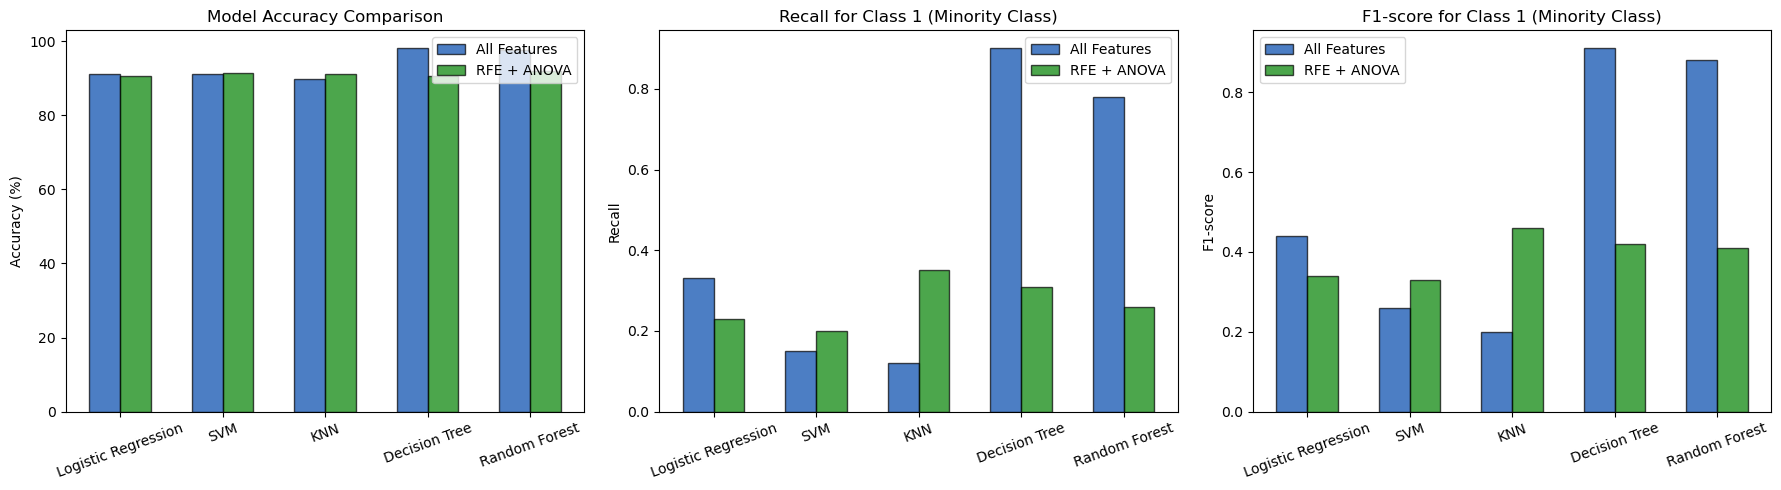

In [113]:
# For class 1 (Minority class)
# Models
models = ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest"]

# Accuracy values (All Features vs. RFE + ANOVA Features)
accuracy_all = [91.21, 91.02, 89.85, 98.03, 97.72]
accuracy_rfe_anova = [90.59, 91.51, 91.14, 90.71, 92.00]

# Recall for Class 1 (minority class)
recall_class1_all = [0.33, 0.15, 0.12, 0.90, 0.78]
recall_class1_rfe_anova = [0.23, 0.20, 0.35, 0.31, 0.26]

# F1-score for Class 1 (minority class)
f1_class1_all = [0.44, 0.26, 0.20, 0.91, 0.88]
f1_class1_rfe_anova = [0.34, 0.33, 0.46, 0.42, 0.41]

# Plot settings
x = np.arange(len(models))
width = 0.3

# Add colors
color_all = "#0047AB"  
color_rfe = "#008000"
                           
fig, axes = p.subplots(1, 3, figsize=(18, 5))

# Accuracy Plot
axes[0].bar(x - width/2, accuracy_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[0].bar(x + width/2, accuracy_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20)
axes[0].legend()

# Recall Class 1 Plot
axes[1].bar(x - width/2, recall_class1_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, recall_class1_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[1].set_title("Recall for Class 1 (Minority Class)")
axes[1].set_ylabel("Recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20)
axes[1].legend()

# F1-score Class 1 Plot
axes[2].bar(x - width/2, f1_class1_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[2].bar(x + width/2, f1_class1_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[2].set_title("F1-score for Class 1 (Minority Class)")
axes[2].set_ylabel("F1-score")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20)
axes[2].legend()

p.tight_layout()
p.show()

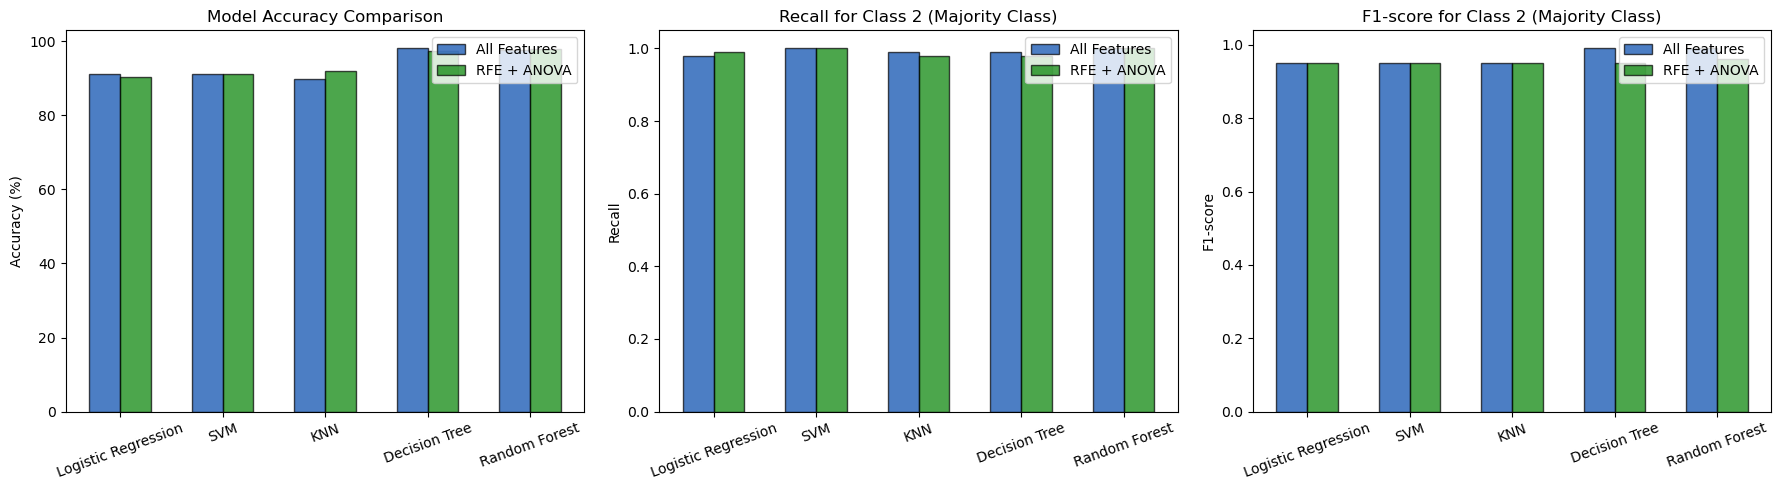

In [114]:
# For class 2 (Majority class)
# Models
models = ["Logistic Regression", "SVM", "KNN", "Decision Tree", "Random Forest"]

# Accuracy values (All Features vs. RFE + ANOVA Features)
accuracy_all = [91.21, 91.02, 89.85, 98.03, 97.72]
accuracy_rfe_anova = [90.35, 91.27, 91.88, 97.48, 97.78]

# Recall for Class 2 (majority class)
recall_class2_all = [0.98, 1.00, 0.99, 0.99, 1.00]
recall_class2_rfe_anova = [0.99, 1.00, 0.98, 0.98, 1.00]

# F1-score for Class 2 (majority class)
f1_class2_all = [0.95, 0.95, 0.95, 0.99, 0.99]
f1_class2_rfe_anova = [0.95, 0.95, 0.95, 0.95, 0.96]

# Plot settings
x = np.arange(len(models))
width = 0.3

# Add colors
color_all = "#0047AB"  
color_rfe = "#008000"


fig, axes = p.subplots(1, 3, figsize=(18, 5))

# Accuracy Plot
axes[0].bar(x - width/2, accuracy_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[0].bar(x + width/2, accuracy_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20)
axes[0].legend()

# Recall Class 2 Plot
axes[1].bar(x - width/2, recall_class2_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[1].bar(x + width/2, recall_class2_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[1].set_title("Recall for Class 2 (Majority Class)")
axes[1].set_ylabel("Recall")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20)
axes[1].legend()

# F1-score Class 2 Plot
axes[2].bar(x - width/2, f1_class2_all, width, label="All Features", color=color_all, alpha=0.7, edgecolor='black')
axes[2].bar(x + width/2, f1_class2_rfe_anova, width, label="RFE + ANOVA", color=color_rfe, alpha=0.7, edgecolor='black')
axes[2].set_title("F1-score for Class 2 (Majority Class)")
axes[2].set_ylabel("F1-score")
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=20)
axes[2].legend()

p.tight_layout()
p.show()

# Check the overfitting in model (Random Forest).

In [115]:
# Find accuracy of train and test data to see the overfitting in model.(Random Forest with all feature) 
train_acc = accuracy_score(trainY, rf.predict(trainstd)) * 100
test_acc = accuracy_score(testY, rf.predict(teststd)) * 100

print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")

Training Accuracy: 100.00%
Test Accuracy: 97.60%


There is no overfitting in Random Forest model (all features). 

# SMOTE to balance the data (all features)

In [117]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)

# Apply SMOTE on the training set
trainX_smote, trainY_smote = smote.fit_resample(trainX, trainY)

# Check class distribution before and after SMOTE
print("Before SMOTE:", Counter(trainY))
print("After SMOTE:", Counter(trainY_smote))

Before SMOTE: Counter({2.0: 5815, 1.0: 684})
After SMOTE: Counter({2.0: 5815, 1.0: 5815})


In [118]:
# Standardize the training data
scaler = StandardScaler()
trainX_smote_scaled = scaler.fit_transform(trainX_smote)

# Standardize the test data 
testX_scaled = scaler.transform(testX)

# Convert back to DataFrame 
trainX_smote_scaled = pd.DataFrame(trainX_smote_scaled, columns=trainX.columns)
testX_scaled = pd.DataFrame(testX_scaled, columns=testX.columns)

# SVM model with balanced data.

In [119]:
# Model Development
svm_model=SVC().fit(trainX_smote_scaled, trainY_smote)
# Prediction of Support Vector Machine with all Features
svm_preds=svm_model.predict(testX_scaled)

# Evaluation Metrics

In [120]:
print(confusion_matrix(testY,svm_preds))

[[  45  127]
 [   4 1451]]


In [121]:
print(classification_report(testY, svm_preds))

              precision    recall  f1-score   support

         1.0       0.92      0.26      0.41       172
         2.0       0.92      1.00      0.96      1455

    accuracy                           0.92      1627
   macro avg       0.92      0.63      0.68      1627
weighted avg       0.92      0.92      0.90      1627



In [122]:
print("Acccuracy of SVM:", accuracy_score(testY, svm_preds)*100)

Acccuracy of SVM: 91.94837123540258


# Random Forest with balanced data.

In [123]:
# Model development 
rf_model=RandomForestClassifier().fit(trainX_smote_scaled, trainY_smote)
# Prediction of Random Forest (with all features)
rf_preds=rf_model.predict(testX_scaled)

# Evaluation Metrics

In [124]:
print(confusion_matrix(testY,rf_preds))

[[ 137   35]
 [   3 1452]]


In [125]:
print(classification_report(testY, rf_preds))

              precision    recall  f1-score   support

         1.0       0.98      0.80      0.88       172
         2.0       0.98      1.00      0.99      1455

    accuracy                           0.98      1627
   macro avg       0.98      0.90      0.93      1627
weighted avg       0.98      0.98      0.98      1627



In [126]:
print("Accuracy of Random Forest(After SMOTE):", accuracy_score(testY, rf_preds)*100)

Accuracy of Random Forest(After SMOTE): 97.66441303011678


# Check the overfitting in model(Random Forest & SVM after SMOTE)

In [127]:
# Find accuracy of train and test data to see the overfitting in model. (Random Forest)
train_acc_smote= accuracy_score(trainY_smote, rf_model.predict(trainX_smote_scaled)) * 100
test_acc_smote = accuracy_score(testY, rf_model.predict(testX_scaled)) * 100

print(f"Training Accuracy - Random Forest (SMOTE): {train_acc_smote:.2f}%")
print(f"Test Accuracy - Random Forest (SMOTE): {test_acc_smote:.2f}%")

Training Accuracy - Random Forest (SMOTE): 100.00%
Test Accuracy - Random Forest (SMOTE): 97.66%


In [128]:
# Find accuracy of train and test data to see the overfitting in model.
train_acc_svm= accuracy_score(trainY_smote, svm_model.predict(trainX_smote_scaled)) * 100
test_acc_svm = accuracy_score(testY, svm_model.predict(testX_scaled)) * 100

print(f"Training Accuracy - SVM (SMOTE): {train_acc_svm:.2f}%")
print(f"Test Accuracy - SVM (SMOTE): {test_acc_svm:.2f}%")

Training Accuracy - SVM (SMOTE): 96.00%
Test Accuracy - SVM (SMOTE): 91.95%


# Logistic Regression with balanced data

In [129]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr2=LogisticRegression().fit(trainX_smote_scaled, trainY_smote)
# Prediction of Logistics Regression (all features)
lr2predict=lr.predict(testX_scaled)

# Evaluation Metrics

In [130]:
print(confusion_matrix(testY, lr2predict))

[[  27  145]
 [   5 1450]]


In [131]:
print(classification_report(testY, lr2predict))

              precision    recall  f1-score   support

         1.0       0.84      0.16      0.26       172
         2.0       0.91      1.00      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.88      0.58      0.61      1627
weighted avg       0.90      0.91      0.88      1627



In [132]:
accuracy_score(testY,lr2predict)*100

90.78057775046096

# KNN with balanced data

In [133]:
# Model development 
knn_model=KNeighborsClassifier().fit(trainX_smote_scaled, trainY_smote)
# Prediction of K-Nearest 
knn_predict=knn_model.predict(testX_scaled)

In [134]:
print(confusion_matrix(testY,knn_predict))

[[  62  110]
 [  39 1416]]


In [135]:
print(classification_report(testY,knn_predict))

              precision    recall  f1-score   support

         1.0       0.61      0.36      0.45       172
         2.0       0.93      0.97      0.95      1455

    accuracy                           0.91      1627
   macro avg       0.77      0.67      0.70      1627
weighted avg       0.89      0.91      0.90      1627



In [136]:
accuracy_score(testY,knn_predict)*100

90.84204056545789

# Best model was Random forest (All Features) with 98% of accuarcy.